##### Copyright 2024 Google LLC.

In [1]:
# @title Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# Keras PaliGemma 2 Quickstart

This is a quick demo of [PaliGemma 2](https://ai.google.dev/gemma/docs/paligemma) running on Keras

We'll explore image captioning and object detection using 3B weights, fine-tuned with 448*448 input images on the [DOCCI](https://google.github.io/docci/) dataset.

<table align="left">
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/google-gemma/cookbook/blob/main/.archive/PaliGemma/[PaliGemma_2]Keras_Quickstart.ipynb"><img src="https://www.tensorflow.org/images/colab_logo_32px.png" />Run in Google Colab</a>
  </td>
  <td>
    <a target="_blank" href="https://github.com/google-gemini/gemma-cookbook/blob/main/PaliGemma/[PaliGemma_2]Keras_Quickstart.ipynb"><img src="https://www.tensorflow.org/images/GitHub-Mark-32px.png" />View source on GitHub</a>
  </td>
</table>


## Setup

### Select the Colab runtime

To complete this tutorial, you'll need to have a Colab runtime with sufficient resources to run the Gemma model:

1. In the upper-right of the Colab window, select **▾ (Additional connection options)**.
2. Select **Change runtime type**.
3. Under **Hardware accelerator**, select **T4 GPU**.


### Gemma setup on Kaggle

To complete this tutorial, you'll first need to complete the setup instructions at [Gemma setup](https://ai.google.dev/gemma/docs/setup), as PaliGemma is a Gemma variant.

In brief, you will need to

* Get access to Gemma on kaggle.com.
* Generate and configure a Kaggle username and API key.

After you've completed the Gemma setup, move on to the next section, where you'll set your username and API key as environment variables for your Colab environment.

### Set environment variables

Set environment variables for `KAGGLE_USERNAME` and `KAGGLE_KEY`.

In [2]:
import os
from google.colab import userdata

# Note: `userdata.get` is a Colab API. If you're not using Colab, set the env
# vars as appropriate for your system.
os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
os.environ["KAGGLE_KEY"] = userdata.get("KAGGLE_KEY")

### Install dependencies

Install Keras and KerasNLP.

In [ ]:
# Install Keras and KerasHub
!pip install -q -U keras keras-hub

# Set the backbend before importing Keras
os.environ["KERAS_BACKEND"] = "jax"
# Avoid memory fragmentation on JAX backend.
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "1.00"

import keras_hub
import keras
# Run at half precision.
keras.config.set_floatx("bfloat16")

## Load Image

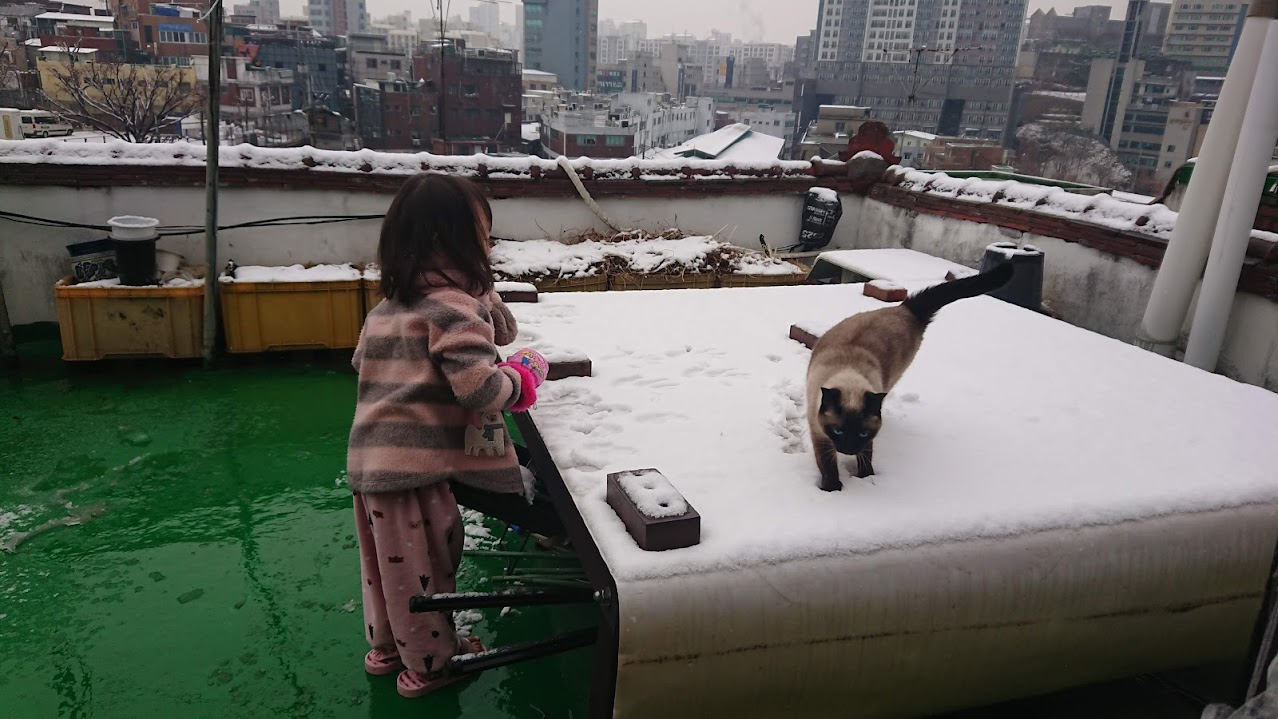

In [4]:
import numpy as np
from PIL import Image, ImageDraw, ImageFont
from keras.utils import img_to_array
import requests

img_url = "https://github.com/bebechien/gemma/blob/main/PaliGemma_Demo.JPG?raw=true"
input_image = Image.open(requests.get(img_url, stream=True).raw)

from IPython.display import display
display(input_image)

###############################
# some helper functions below #
###############################
import cv2
import re

def draw_bounding_box(image, coordinates, label, label_colors, width, height):
    y1, x1, y2, x2 = coordinates
    y1, x1, y2, x2 = map(round, (y1*height, x1*width, y2*height, x2*width))

    text_size, _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 1, 3)
    text_width, text_height = text_size

    text_x = x1 + 2
    text_y = y1 - 5

    font_scale = 1
    label_rect_width = text_width + 8
    label_rect_height = int(text_height * font_scale)

    color = label_colors.get(label, None)
    if color is None:
        color = np.random.randint(0, 256, (3,)).tolist()
        label_colors[label] = color

    cv2.rectangle(image, (x1, y1 - label_rect_height), (x1 + label_rect_width, y1), color, -1)

    thickness = 2
    cv2.putText(image, label, (text_x, text_y), cv2.FONT_HERSHEY_SIMPLEX, font_scale, (255, 255, 255), thickness, cv2.LINE_AA)

    cv2.rectangle(image, (x1, y1), (x2, y2), color, 2)
    return image

def draw_results(paligemma_response):
  detections = paligemma_response.split(" ; ")
  parsed_coordinates = []
  labels = []
  label_colors = {}
  output_image = input_image
  output_img = np.array(input_image)

  if len(detections) > 1:
    for item in detections:
      detection = item.replace("<loc", "").split()

      if len(detection) >= 2:
        coordinates_str = detection[0]
        coordinates = coordinates_str.split(">")
        coordinates = coordinates[:4]

        if coordinates[-1] == '':
          coordinates = coordinates[:-1]

        coordinates = [int(coord)/1024 for coord in coordinates]
        parsed_coordinates.append(coordinates)

        for label in detection[1:]:
          if "<seg" in label:
            continue
          else:
            labels.append(label)

      else:
        # No label detected, skip the iteration.
        continue

      width = input_image.size[0]
      height = input_image.size[1]

      # Draw bounding boxes on the frame.
      image = cv2.cvtColor(np.array(input_image), cv2.COLOR_RGB2BGR)
      for coordinates, label in zip(parsed_coordinates, labels):
        output_img = draw_bounding_box(output_img, coordinates, label, label_colors, width, height)

      output_image = Image.fromarray(output_img)

  elif len(detections) == 1:
    for item in detections:
      detection = item.split("<loc")

      if len(detection) >= 5:
        coordinates = []
        for value in detection[1:5]:
          coordinates.append(value.split(">")[0])

        if coordinates[-1] == '':
          coordinates = coordinates[:-1]

        coordinates = [int(coord)/1024 for coord in coordinates]
        parsed_coordinates.append(coordinates)
        labels.append("object")

      else:
        # No label detected, skip the iteration.
        continue

      width = input_image.size[0]
      height = input_image.size[1]

      # Draw bounding boxes on the frame.
      image = cv2.cvtColor(np.array(input_image), cv2.COLOR_RGB2BGR)
      for coordinates, label in zip(parsed_coordinates, labels):
        output_img = draw_bounding_box(output_img, coordinates, label, label_colors, width, height)

      output_image = Image.fromarray(output_img)

  return output_image

## Load Model

In [5]:
model_name = "kaggle://keras/paligemma2/keras/pali_gemma_2_ft_docci_3b_448"

# we need to resize the image to the size expected by the model
# we're assuming the model name ends with _NUM here
target_size_x = int(model_name[model_name.rfind("_") + 1 :])
target_size = (target_size_x, target_size_x)

pali_gemma_lm = keras_hub.models.PaliGemmaCausalLM.from_preset(model_name)
pali_gemma_lm.summary()

100%|██████████| 1.06k/1.06k [00:00<00:00, 1.37MB/s]


100%|██████████| 5.65G/5.65G [01:56<00:00, 52.3MB/s]


100%|██████████| 431/431 [00:00<00:00, 280kB/s]


100%|██████████| 4.07M/4.07M [00:00<00:00, 9.33MB/s]


100%|██████████| 510/510 [00:00<00:00, 609kB/s]


...

Model: "pali_gemma_causal_lm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ images (InputLayer)           │ (None, 448, 448, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ padding_mask (InputLayer)     │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ response_mask (InputLayer)    │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ token_ids (InputLayer)        │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pali_gemma_backbone           │ (None, None, 2304)        │   3,032,979,696 │ images[0][0],              │
│ (PaliGemmaBackbone)           │                           │                 │ padding_mask[0][0],        │
│                               │                           │                 │ response_mask[0][0],       │
│                               │                           │                 │ token_ids[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ token_embedding               │ (None, None, 257152)      │     592,478,208 │ pali_gemma_backbone[0][0]  │
│ (ReversibleEmbedding)         │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ get_item (GetItem)            │ (None, None, 257152)      │               0 │ token_embedding[1][0]      │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 3,032,979,696 (5.65 GB)

 Trainable params: 3,032,979,696 (5.65 GB)

 Non-trainable params: 0 (0.00 B)

## Inference

<image>caption en
A medium view of a girl and a cat on a rooftop. The girl is facing the right side and is looking at a brown cat that is standing on a white carpet that is covered in snow. The cat is looking at the girl, and its tail is sticking out to the right. The carpet is green, and the ground is also green. The girl is wearing a pink and gray striped sweater and pants. On the left side of the carpet, there is a yellow box that is filled with snow. Behind the cat and girl, there is a white wall that has a red brick border. On the other side of the wall, there are many buildings that are covered in snow.


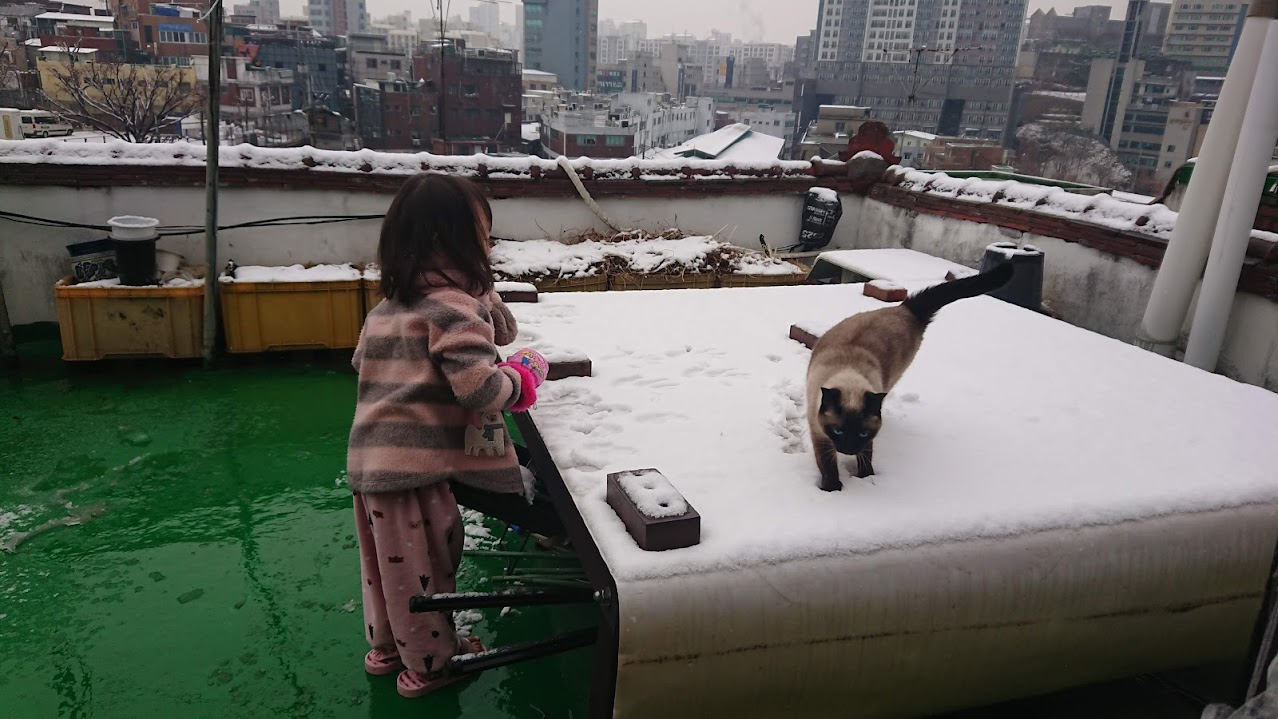

In [11]:
########
input_text = "<image>caption en\n"
result = pali_gemma_lm.generate(
    inputs={
        "images": img_to_array(input_image.resize(target_size)),
        "prompts": input_text,
    }
)
print(result)

draw_results(result[len(input_text):])

detect  cat ; person
<loc0240><loc0277><loc0990><loc0435> <seg027><seg009><seg060><seg088><seg021><seg116><seg064><seg055><seg000><seg066><seg114><seg089><seg027><seg063><seg057><seg089> person ; <loc0362><loc0644><loc0699><loc0825> <seg114><seg041><seg037><seg121><seg029><seg073><seg060><seg089><seg051><seg117><seg074><seg012><seg044><seg116><seg057><seg012> cat


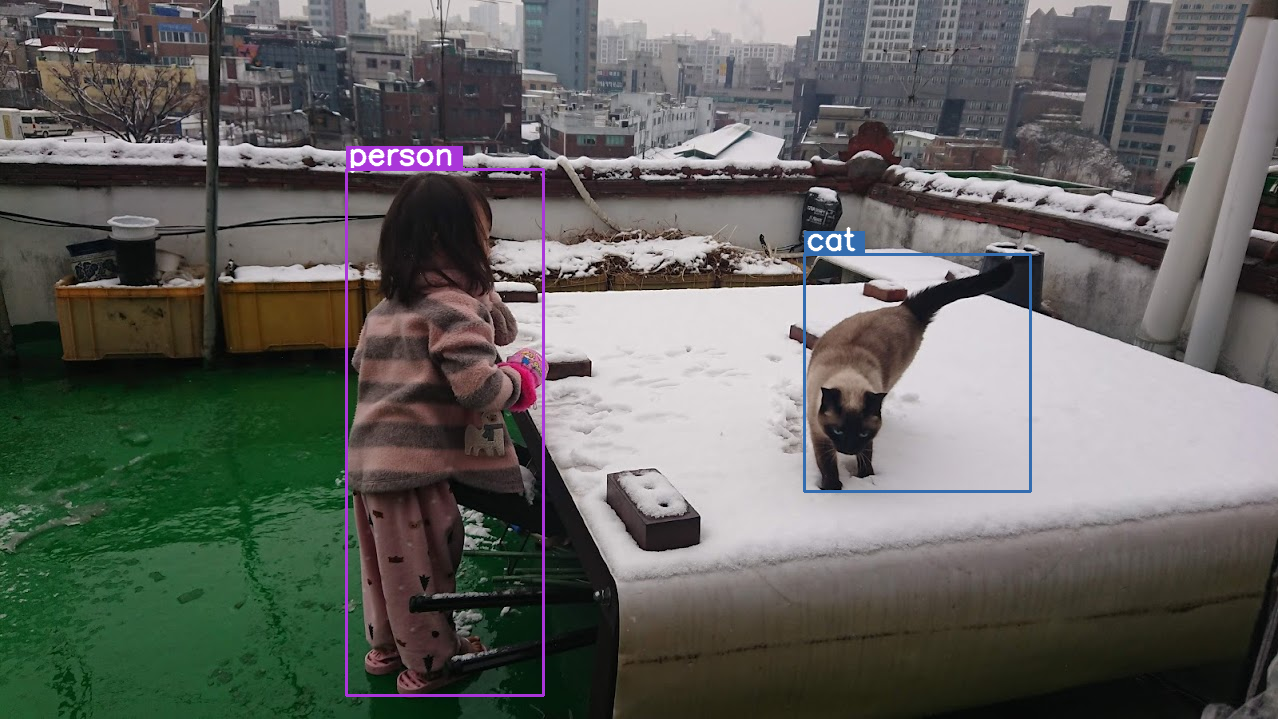

In [10]:
########
input_text = "detect  cat ; person\n"
result = pali_gemma_lm.generate(
    inputs={
        "images": img_to_array(input_image.resize(target_size)),
        "prompts": input_text,
    }
)
print(result)

draw_results(result[len(input_text):])
